# Emulators

Emulators are core components of the history matching algorithm. An emulator is a function that allows us to predict the output of a model for a set of input parameters, along with some uncertainty measures. An important characteristic of an emulator is that its execution time is much faster than the execution time of a model. The `emulators` module of our package contains some emulators. Here we describe how to use the emulators included in the `history_matching` package. 

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. We also use the `emulator` module from our library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching.emulators as emulators

%matplotlib inline




Loaded tensorflow-probability version 0.24.0.
Loaded tensorflow-probability version 0.24.0.


## Example scenarios

### Linear model (1D)

Let's define a linear model in 1 dimension. In its simplest form, this model receives a single parameter $\theta$
 and outputs a scalar. This scalar is computed as $b_0 + b_1 \theta + \mathcal{N}(0, \sigma)$, with $b_0$, $b_1$, and $\sigma$ being hyper-parameters that, for all the purposes in this example, are constant (and unknown to an emulator).

In the Python function that implements this model, we extend this definition and apply it to a set of parameters $\theta$, which are defined as separate rows of an input dataframe x. Consequently, this function computes the corresponding outputs and returns them in an output dataframe.

In [2]:
def linear_model( x: pd.DataFrame(), b0=1, b1=2, sigma=7.5 ):
    """
    1-D linear model. Using the value of theta in each row of the 
    input dataframe, the model computes outputs in an output dataframe
    as: 
            b0 + b1*theta + mu,
    with mu being drawn from a 0-mean normal distribution with standard
    deviation sigma.
    """
    y = b0 + b1*x['theta'] + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Now, let's see how this model works. We can do that by defining the parameter space as the interval [`theta_min`, `theta_max`], and then sampling some points in that space. We then call our model and plot the outputs. As expected in this case, we see that the output is a noisy line.

<Axes: title={'center': 'Linear model'}, xlabel='theta', ylabel='data'>

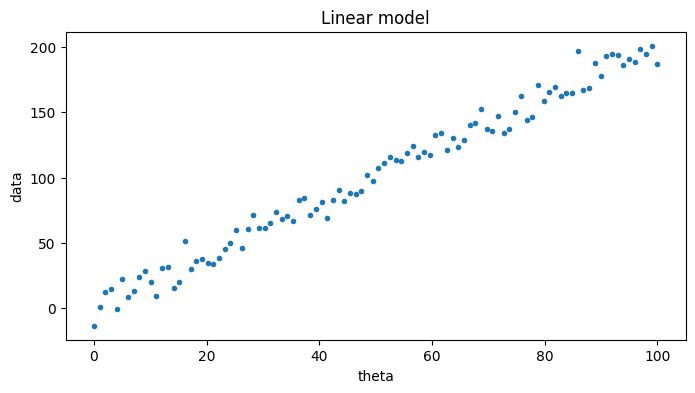

In [3]:
# Sample parameters from a grid
theta_min = 0
theta_max = 100
n = 100
x = pd.DataFrame( { 'theta' : np.linspace( theta_min, theta_max, n ) } )

# Run the model and plot outputs
y = linear_model(x)
xy_model = pd.DataFrame( { 'theta' : x['theta'].values,
                           'data'  : y['out'].values
                          } )

xy_model.plot( title='Linear model', x='theta', y='data', ylabel='data', legend=False, style='.', figsize=(8,4))

## Working with a linear model emulator

One of the most basic emulators is the linear regression emulator. This emulator is defined by the `emulators.LinearModel` class.s:

### Instantiating and training the emulator


We can train our emulator by instantiating it with some input data (such as the one created above using the linear model), and then calling th`e train`() method, as follows:

In [4]:
linear_emulator = emulators.LinearModel(x, y)
linear_emulator.train()

We can get information about the emulator object by using the `info()` method:

In [5]:
linear_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  100
      Number of training samples =  75
      Number of testing samples =  25

... Emulator configuration:
      coefficients:  [[1.9714183]]
      intercept   :  [2.66299087]

      This emulator has not been tested yet


Note that the general information above contains a default number of testing and training samples. We can explicitly indicate what fraction of the data to use for testing by setting the `test_fraction` argument when instantiating the emulator object. For example, if we want to use 50% of the data for testing, we can set our emulator as `linear_emulator = emulators.LinearModel(x, y, test_fraction=0.5).`s:

### Predicting outputs

Once we have trained our emulator, we can use it for predicting some outputs:

In [6]:
x_predict = pd.DataFrame( { 'theta' : np.linspace( theta_max+1, 2*theta_max, n ) } )
y_predict = linear_emulator.predict( x_predict )
print( y_predict.head() )

        value         low        high
0  201.776239  108.501683  295.050795
1  203.747657  110.473101  297.022213
2  205.719075  112.444519  298.993631
3  207.690494  114.415938  300.965050
4  209.661912  116.387356  302.936468


Let's compare the training and predicted data:

<Axes: xlabel='theta', ylabel='output'>

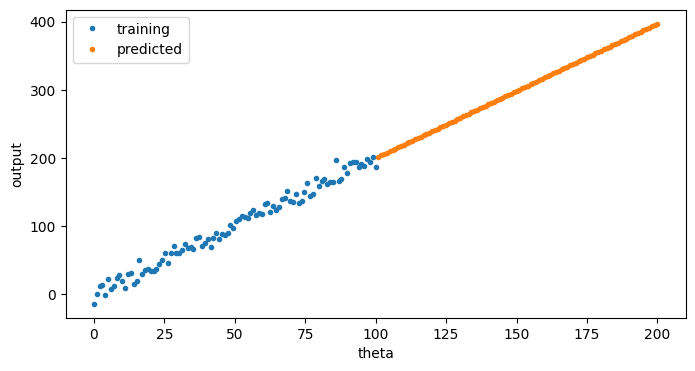

In [7]:
fig_pred, ax_pred = plt.subplots(1, 1, figsize=(8,4) )
xy = pd.DataFrame( { 'theta'    : x['theta'].values ,
                     'training' : y['out'].values
                    } )
xy = pd.concat( [ xy, pd.DataFrame( { 'theta' : x_predict['theta'].values,
                                      'predicted' : y_predict['value'].values
                                     } ) 
                 ], ignore_index=True )
xy.plot(x='theta', style='.', ylabel='output', ax=ax_pred )

In addition to the predicted value, the `predict()` method gives us lower and upper uncertainty bounds. In this emulator, those bounds are defined by default by the 5th and 95th percentiles of the normal distribution centered at the predicted value, and with variance estimated from the training data. We can change these percentiles by modifying some arguments in the call for predicting outputs:

In [8]:
y_predict_new_quantiles = linear_emulator.predict( x_predict, qlow=0.25, qhi=0.75 )
print( y_predict_new_quantiles.head() )

        value         low        high
0  201.776239  163.528013  240.024464
1  203.747657  165.499432  241.995882
2  205.719075  167.470850  243.967300
3  207.690494  169.442268  245.938719
4  209.661912  171.413687  247.910137


### Evaluating the performance of our emulator

We can run some diagnostics and evaluate the performance of our emulator using the` test(`) method:

In [9]:
linear_emulator.test()

A summary of the performance results can now be seen when calling the `info()` method:

In [10]:
linear_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  100
      Number of training samples =  75
      Number of testing samples =  25

... Emulator configuration:
      coefficients:  [[1.9714183]]
      intercept   :  [2.66299087]

... Performance results:
      MSE =  49.38149688240469
      R2 =  nan


We can get more detailed information by plotting diagnostics. These are a set of figures that can provide some deeper information that the one that is quantified in the summarized performance results.

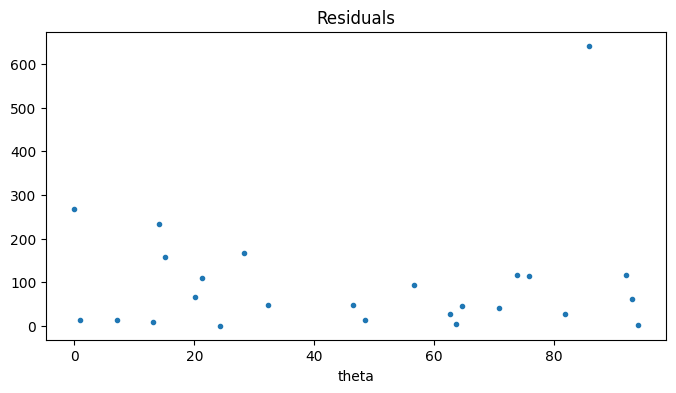

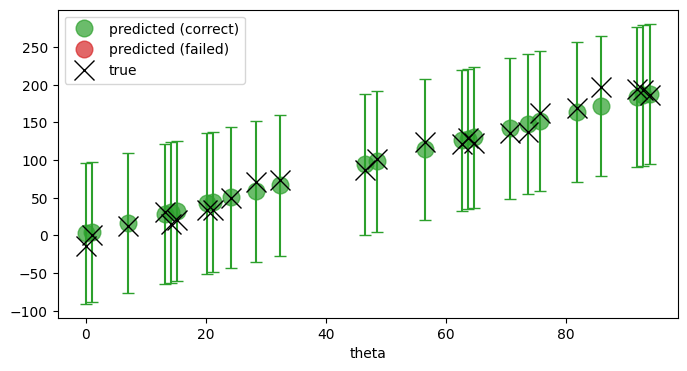

In [11]:
linear_emulator.plot_diagnostics()

### Computing impausibilty measures

We can compute the implausibility measure used in the history matching algorithm by calling the `get_implausibility()` method:

In [29]:
target_value = 100
target_var = 7.5
x_imp = pd.DataFrame( { 'theta' : np.linspace( 0, 100, 50 ) } )

linear_model_implausibility = linear_emulator.get_implausibility( x_imp, target_value, target_var )

<Axes: xlabel='theta'>

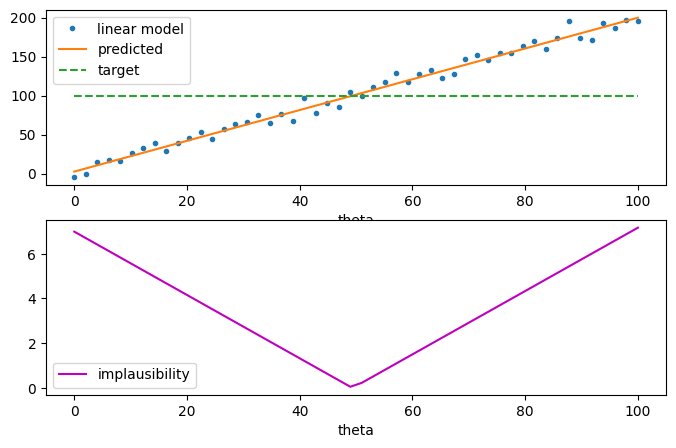

In [59]:
fig_imp, axs_imp = plt.subplots(2, 1, figsize=(8,5) )


lm_imp = pd.DataFrame( { 'theta'    : x_imp['theta'].values,
                         'linear model' : linear_model(x_imp)['out'].values,
                         'predicted'    : linear_emulator.predict(x_imp['theta'])['value'].values,
                         'target'       : target_value,
                         'implausibility' : linear_model_implausibility
                    } )

lm_imp.plot( x='theta', y=['linear model', 'predicted', 'target'], style=['.','-','--'], ax=axs_imp[0] )
lm_imp.plot( x='theta', y='implausibility', c='m', ax=axs_imp[1] )